In [ ]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("2019.csv")
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


Generosity                      0.075824
Perceptions of corruption       0.385613
Freedom to make life choices    0.566742
Social support                  0.777058
Healthy life expectancy         0.779883
GDP per capita                  0.793883
Name: Score, dtype: float64


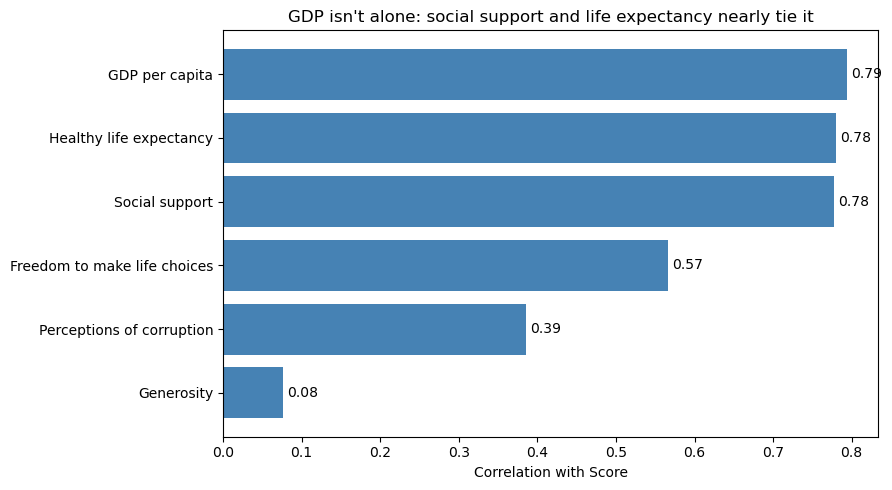

In [14]:
import matplotlib.pyplot as plt

factors = ["GDP per capita", "Social support", "Healthy life expectancy",
           "Freedom to make life choices", "Generosity", "Perceptions of corruption"]

# Корреляция каждого фактора со Score, по возрастанию (для barh)
corr = df[factors + ["Score"]].corr()["Score"].drop("Score").sort_values()
print(corr)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(corr.index, corr.values, color="steelblue")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)

ax.set_xlabel("Correlation with Score")
ax.set_title("GDP isn't alone: social support and life expectancy nearly tie it")

plt.tight_layout()
plt.show()

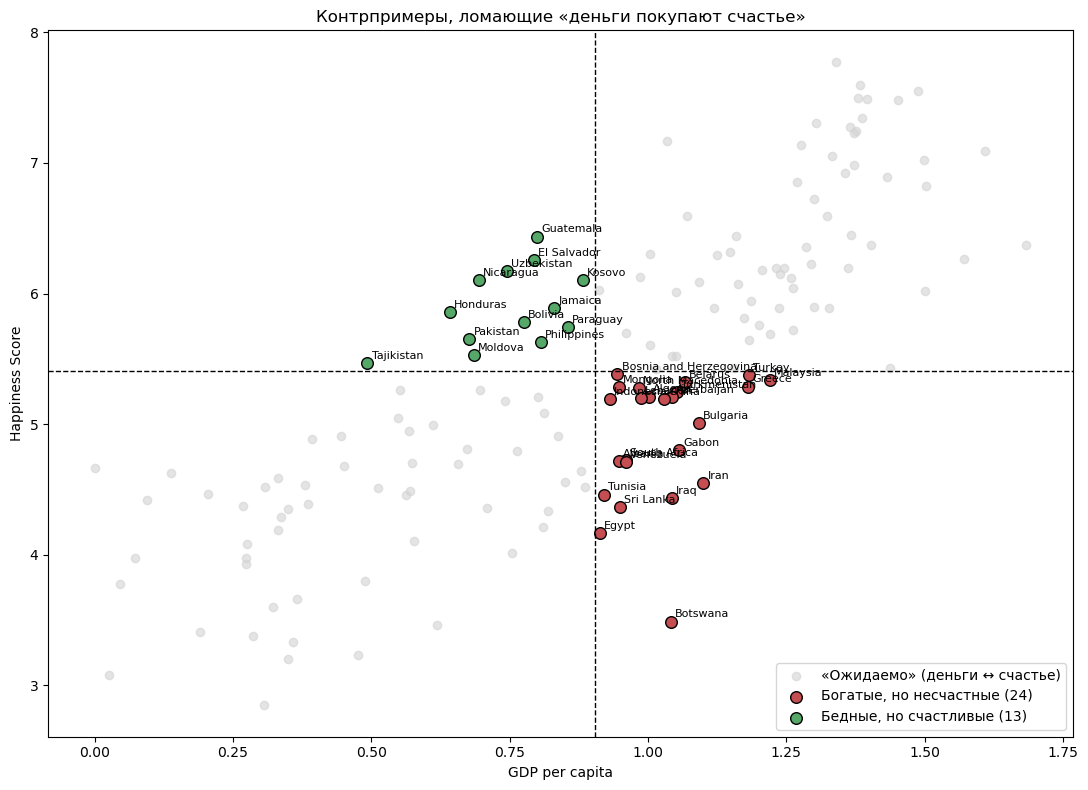

In [30]:
import matplotlib.pyplot as plt

gdp_mean = df["GDP per capita"].mean()
score_mean = df["Score"].mean()

# Классификация по квадрантам относительно средних
def quadrant(r):
    if r["GDP per capita"] > gdp_mean and r["Score"] < score_mean:
        return "rich_unhappy"     # богатые, но несчастные
    if r["GDP per capita"] < gdp_mean and r["Score"] > score_mean:
        return "poor_happy"       # бедные, но счастливые
    return "expected"

df["quad"] = df.apply(quadrant, axis=1)

fig, ax = plt.subplots(figsize=(11, 8))

# "Ожидаемые" страны — приглушённый фон
exp = df[df["quad"] == "expected"]
ax.scatter(exp["GDP per capita"], exp["Score"], color="lightgray", alpha=0.6,
           label="«Ожидаемо» (деньги ↔ счастье)")

# Контрпримеры — яркие
ru = df[df["quad"] == "rich_unhappy"]
ph = df[df["quad"] == "poor_happy"]
ax.scatter(ru["GDP per capita"], ru["Score"], color="#c44e52", s=70, edgecolor="black",
           label=f"Богатые, но несчастные ({len(ru)})")
ax.scatter(ph["GDP per capita"], ph["Score"], color="#55a868", s=70, edgecolor="black",
           label=f"Бедные, но счастливые ({len(ph)})")

# Подписи стран-контрпримеров
for _, r in pd.concat([ru, ph]).iterrows():
    ax.annotate(r["Country or region"], (r["GDP per capita"], r["Score"]),
                fontsize=8, xytext=(3, 3), textcoords="offset points")

# Линии средних делят поле на квадранты
ax.axvline(gdp_mean, color="black", linestyle="--", linewidth=1)
ax.axhline(score_mean, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("GDP per capita")
ax.set_ylabel("Happiness Score")
ax.set_title("Контрпримеры, ломающие «деньги покупают счастье»")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

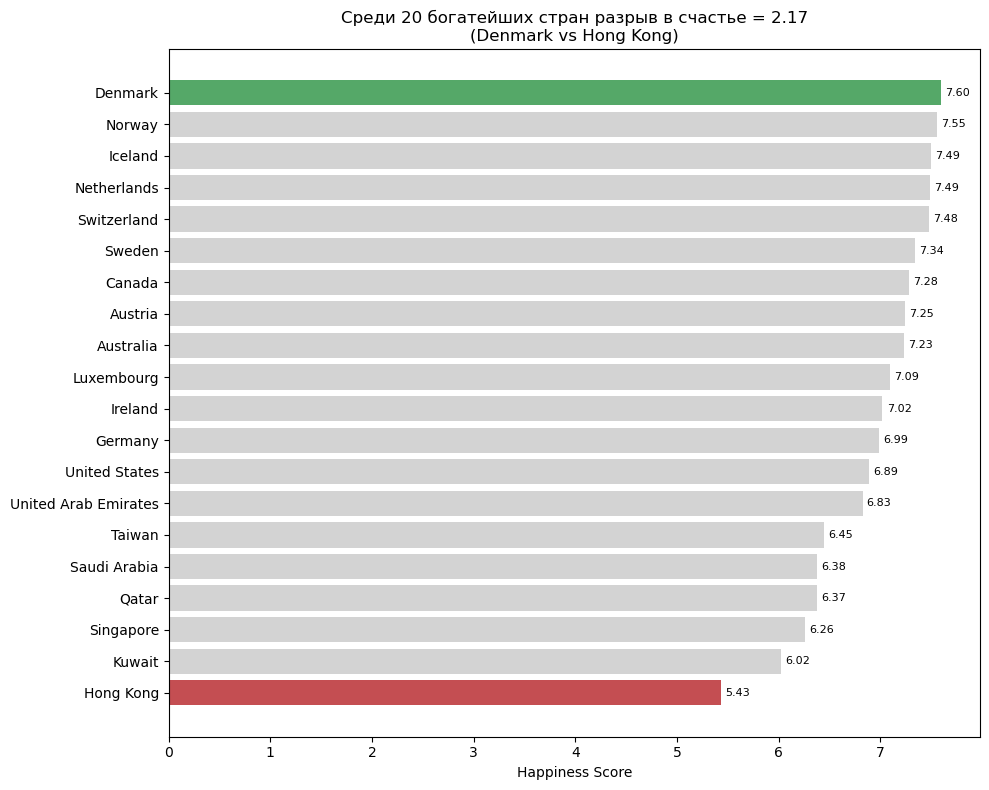

In [35]:
import matplotlib.pyplot as plt

# 20 самых богатых стран по GDP per capita, затем сортировка по Score
richest20 = df.nlargest(20, "GDP per capita").sort_values("Score")

happiest = richest20["Score"].idxmax()
unhappiest = richest20["Score"].idxmin()
gap = richest20["Score"].max() - richest20["Score"].min()

# Цвета: счастливейшая — зелёная, несчастнейшая — красная, остальные — серые
colors = []
for i in richest20.index:
    if i == happiest:
        colors.append("#55a868")
    elif i == unhappiest:
        colors.append("#c44e52")
    else:
        colors.append("lightgray")

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(richest20["Country or region"], richest20["Score"], color=colors)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)

ax.set_xlabel("Happiness Score")
ax.set_title(f"Среди 20 богатейших стран разрыв в счастье = {gap:.2f}\n"
             f"({df.loc[happiest, 'Country or region']} vs {df.loc[unhappiest, 'Country or region']})")

plt.tight_layout()
plt.show()

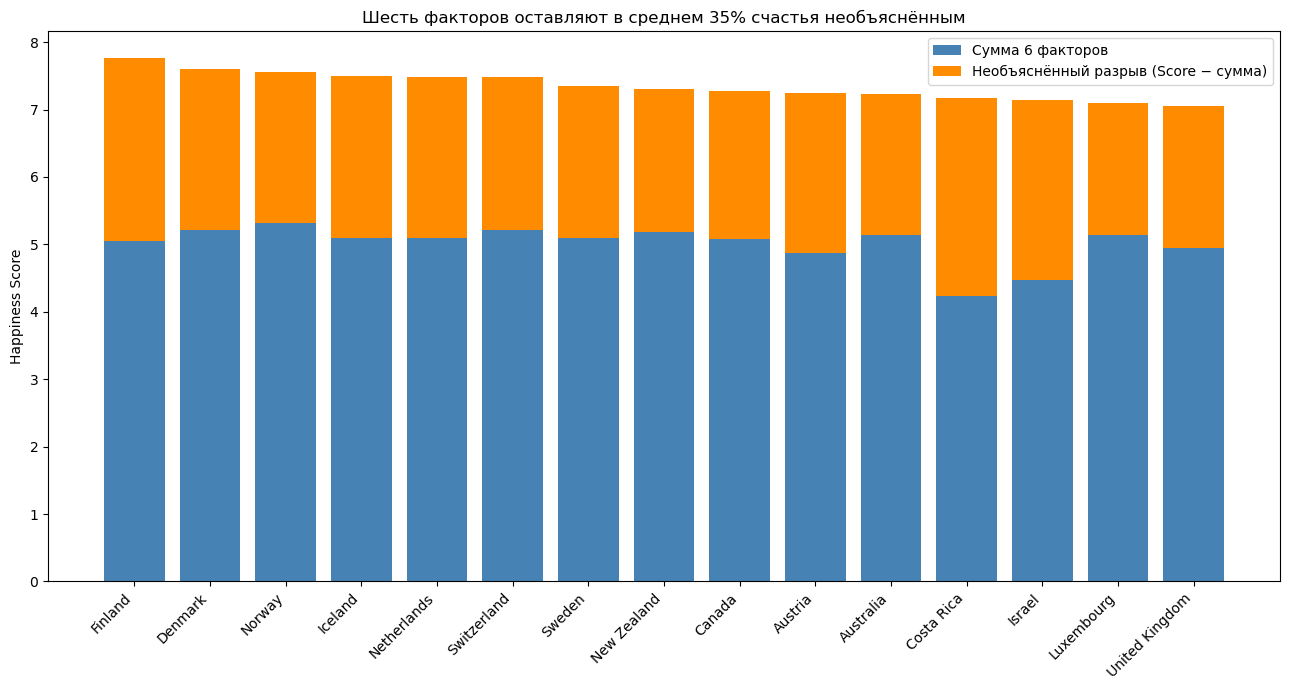

In [36]:
import matplotlib.pyplot as plt

factors = ["GDP per capita", "Social support", "Healthy life expectancy",
           "Freedom to make life choices", "Generosity", "Perceptions of corruption"]
df["factors_sum"] = df[factors].sum(axis=1)
df["residual"] = df["Score"] - df["factors_sum"]

# Доля счастья, которую шесть факторов НЕ объясняют (в среднем по всем странам)
unexplained_share = (df["residual"] / df["Score"]).mean()

# Топ-15 самых счастливых стран
top15 = df.nlargest(15, "Score")

fig, ax = plt.subplots(figsize=(13, 7))
ax.bar(top15["Country or region"], top15["factors_sum"],
       color="steelblue", label="Сумма 6 факторов")
ax.bar(top15["Country or region"], top15["residual"], bottom=top15["factors_sum"],
       color="darkorange", label="Необъяснённый разрыв (Score − сумма)")

ax.set_ylabel("Happiness Score")
ax.set_title(f"Шесть факторов оставляют в среднем {unexplained_share:.0%} счастья необъяснённым")
ax.legend()
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [25]:
#Страны, которые счастливее, чем «положено»
factors = ["GDP per capita","Social support","Healthy life expectancy",
           "Freedom to make life choices","Generosity","Perceptions of corruption"]
df["factors_sum"] = df[factors].sum(axis=1)
df["residual"] = df["Score"] - df["factors_sum"]
df.sort_values("residual", ascending=False).head(10)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,factors_sum,residual,Continent
101,102,Benin,4.883,0.393,0.437,0.397,0.349,0.175,0.082,1.833,3.050,Africa
11,12,Costa Rica,7.167,1.034,1.441,0.963,0.558,0.144,0.093,4.233,2.934,North America
66,67,Pakistan,5.653,0.677,0.886,0.535,0.313,0.220,0.098,2.729,2.924,Asia
26,27,Guatemala,6.436,0.800,1.269,0.746,0.535,0.175,0.078,3.603,2.833,North America
34,35,El Salvador,6.253,0.794,1.242,0.789,0.430,0.093,0.074,3.422,2.831,North America
22,23,Mexico,6.595,1.070,1.323,0.861,0.433,0.074,0.073,3.834,2.761,North America
113,114,Niger,4.628,0.138,0.774,0.366,0.318,0.188,0.102,1.886,2.742,Africa
98,99,Ivory Coast,4.944,0.569,0.808,0.232,0.352,0.154,0.090,2.205,2.739,Africa
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,5.055,2.714,Europe
12,13,Israel,7.139,1.276,1.455,1.029,0.371,0.261,0.082,4.474,2.665,Asia


/var/folders/xw/20s6937n15j4qt32krtk13_w0000gn/T/ipykernel_25387/2145355202.py:15: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



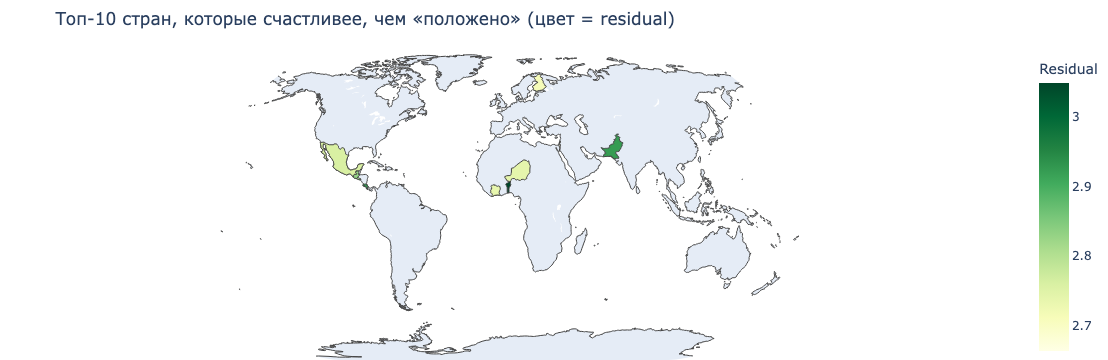

In [32]:
import plotly.express as px

# Топ-10 стран, которые счастливее, чем «положено» (как в ячейке выше)
top10 = df.sort_values("residual", ascending=False).head(10).copy()

# Названия в формате, который понимает Plotly (locationmode="country names")
name_fix = {
    "Ivory Coast": "Cote d'Ivoire",
    "United States": "United States of America",
    "Congo (Brazzaville)": "Republic of the Congo",
    "Congo (Kinshasa)": "Democratic Republic of the Congo",
}
top10["map_name"] = top10["Country or region"].replace(name_fix)

fig = px.choropleth(
    top10,
    locations="map_name",
    locationmode="country names",
    color="residual",
    hover_name="Country or region",
    hover_data={"map_name": False, "Score": True, "residual": ":.3f"},
    color_continuous_scale="YlGn",   # темнее = счастливее, чем «положено»
    title="Топ-10 стран, которые счастливее, чем «положено» (цвет = residual)",
)

fig.update_layout(
    coloraxis_colorbar_title="Residual",
    geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
    margin=dict(l=0, r=0, t=50, b=0),
)
fig.show()

In [33]:
#Страны, которые несчастнее, чем «положено»
factors = ["GDP per capita","Social support","Healthy life expectancy",
           "Freedom to make life choices","Generosity","Perceptions of corruption"]
df["factors_sum"] = df[factors].sum(axis=1)
df["residual"] = df["Score"] - df["factors_sum"]
df.sort_values("residual").head(10)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,factors_sum,residual,Continent,quad
147,148,Botswana,3.488,1.041,1.145,0.538,0.455,0.025,0.100,3.304,0.184,Africa,rich_unhappy
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411,2.867,0.467,Africa,expected
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147,2.700,0.531,Africa,expected
129,130,Sri Lanka,4.366,0.949,1.265,0.831,0.470,0.244,0.047,3.806,0.560,Asia,rich_unhappy
75,76,Hong Kong,5.430,1.438,1.277,1.122,0.440,0.258,0.287,4.822,0.608,Asia,expected
130,131,Myanmar,4.360,0.710,1.181,0.555,0.525,0.566,0.172,3.709,0.651,Asia,expected
33,34,Singapore,6.262,1.572,1.463,1.141,0.556,0.271,0.453,5.456,0.806,Asia,expected
132,133,Ukraine,4.332,0.820,1.390,0.739,0.178,0.187,0.010,3.324,1.008,Europe,expected
116,117,Iran,4.548,1.100,0.842,0.785,0.305,0.270,0.125,3.427,1.121,Asia,rich_unhappy
139,140,India,4.015,0.755,0.765,0.588,0.498,0.200,0.085,2.891,1.124,Asia,expected


/var/folders/xw/20s6937n15j4qt32krtk13_w0000gn/T/ipykernel_25387/756089162.py:15: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



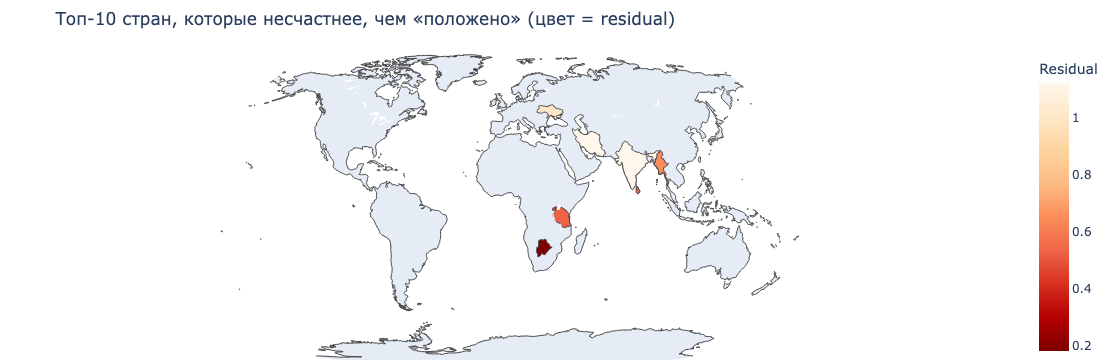

In [34]:
import plotly.express as px

# Нижние 10 стран — несчастнее, чем «положено» (как в ячейке выше)
bottom10 = df.sort_values("residual").head(10).copy()

# Названия в формате, который понимает Plotly (locationmode="country names")
name_fix = {
    "Ivory Coast": "Cote d'Ivoire",
    "United States": "United States of America",
    "Congo (Brazzaville)": "Republic of the Congo",
    "Congo (Kinshasa)": "Democratic Republic of the Congo",
}
bottom10["map_name"] = bottom10["Country or region"].replace(name_fix)

fig = px.choropleth(
    bottom10,
    locations="map_name",
    locationmode="country names",
    color="residual",
    hover_name="Country or region",
    hover_data={"map_name": False, "Score": True, "residual": ":.3f"},
    color_continuous_scale="OrRd_r",   # темнее = сильнее несчастливее, чем «положено»
    title="Топ-10 стран, которые несчастнее, чем «положено» (цвет = residual)",
)

fig.update_layout(
    coloraxis_colorbar_title="Residual",
    geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
    margin=dict(l=0, r=0, t=50, b=0),
)
fig.show()

In [24]:
# Добавляем континент для каждой страны
country_to_continent = {
    # Europe
    "Finland": "Europe", "Denmark": "Europe", "Norway": "Europe", "Iceland": "Europe",
    "Netherlands": "Europe", "Switzerland": "Europe", "Sweden": "Europe", "Austria": "Europe",
    "Luxembourg": "Europe", "United Kingdom": "Europe", "Ireland": "Europe", "Germany": "Europe",
    "Belgium": "Europe", "Czech Republic": "Europe", "Malta": "Europe", "France": "Europe",
    "Spain": "Europe", "Italy": "Europe", "Slovakia": "Europe", "Poland": "Europe",
    "Lithuania": "Europe", "Slovenia": "Europe", "Kosovo": "Europe", "Romania": "Europe",
    "Cyprus": "Europe", "Latvia": "Europe", "Estonia": "Europe", "Hungary": "Europe",
    "Northern Cyprus": "Europe", "Portugal": "Europe", "Russia": "Europe", "Serbia": "Europe",
    "Moldova": "Europe", "Montenegro": "Europe", "Croatia": "Europe",
    "Bosnia and Herzegovina": "Europe", "Belarus": "Europe", "Greece": "Europe",
    "North Macedonia": "Europe", "Bulgaria": "Europe", "Albania": "Europe", "Ukraine": "Europe",

    # Asia
    "Israel": "Asia", "United Arab Emirates": "Asia", "Taiwan": "Asia", "Saudi Arabia": "Asia",
    "Qatar": "Asia", "Singapore": "Asia", "Bahrain": "Asia", "Uzbekistan": "Asia",
    "Kuwait": "Asia", "Thailand": "Asia", "South Korea": "Asia", "Japan": "Asia",
    "Kazakhstan": "Asia", "Tajikistan": "Asia", "Hong Kong": "Asia", "Turkey": "Asia",
    "Malaysia": "Asia", "Mongolia": "Asia", "Kyrgyzstan": "Asia", "Turkmenistan": "Asia",
    "Azerbaijan": "Asia", "Lebanon": "Asia", "Indonesia": "Asia", "China": "Asia",
    "Vietnam": "Asia", "Bhutan": "Asia", "Nepal": "Asia", "Jordan": "Asia", "Laos": "Asia",
    "Palestinian Territories": "Asia", "Armenia": "Asia", "Iran": "Asia", "Georgia": "Asia",
    "Iraq": "Asia", "Sri Lanka": "Asia", "Myanmar": "Asia", "Bangladesh": "Asia",
    "Cambodia": "Asia", "India": "Asia", "Syria": "Asia", "Yemen": "Asia",
    "Afghanistan": "Asia", "Pakistan": "Asia", "Philippines": "Asia",

    # Africa
    "Nigeria": "Africa", "Algeria": "Africa", "Morocco": "Africa", "Cameroon": "Africa",
    "Ghana": "Africa", "Ivory Coast": "Africa", "Benin": "Africa", "Congo (Brazzaville)": "Africa",
    "Gabon": "Africa", "South Africa": "Africa", "Senegal": "Africa", "Somalia": "Africa",
    "Namibia": "Africa", "Niger": "Africa", "Burkina Faso": "Africa", "Guinea": "Africa",
    "Gambia": "Africa", "Kenya": "Africa", "Mauritania": "Africa", "Mozambique": "Africa",
    "Tunisia": "Africa", "Congo (Kinshasa)": "Africa", "Mali": "Africa", "Sierra Leone": "Africa",
    "Chad": "Africa", "Ethiopia": "Africa", "Swaziland": "Africa", "Uganda": "Africa",
    "Egypt": "Africa", "Zambia": "Africa", "Togo": "Africa", "Liberia": "Africa",
    "Comoros": "Africa", "Madagascar": "Africa", "Lesotho": "Africa", "Burundi": "Africa",
    "Zimbabwe": "Africa", "Botswana": "Africa", "Malawi": "Africa", "Rwanda": "Africa",
    "Tanzania": "Africa", "Central African Republic": "Africa", "South Sudan": "Africa",
    "Libya": "Africa", "Mauritius": "Africa",

    # North America (вкл. Центральную Америку и Карибы)
    "Canada": "North America", "Costa Rica": "North America", "Mexico": "North America",
    "Guatemala": "North America", "Panama": "North America", "El Salvador": "North America",
    "Trinidad & Tobago": "North America", "Nicaragua": "North America", "Jamaica": "North America",
    "Honduras": "North America", "Dominican Republic": "North America", "Haiti": "North America",
    "United States": "North America",

    # South America
    "Chile": "South America", "Brazil": "South America", "Uruguay": "South America",
    "Colombia": "South America", "Argentina": "South America", "Ecuador": "South America",
    "Bolivia": "South America", "Paraguay": "South America", "Peru": "South America",
    "Venezuela": "South America",

    # Oceania
    "New Zealand": "Oceania", "Australia": "Oceania",
}

df["Continent"] = df["Country or region"].map(country_to_continent)

# Проверка: какие страны остались без континента
missing = df[df["Continent"].isna()]["Country or region"].tolist()
print("Стран без континента:", len(missing))
print(missing)

Стран без континента: 0
[]


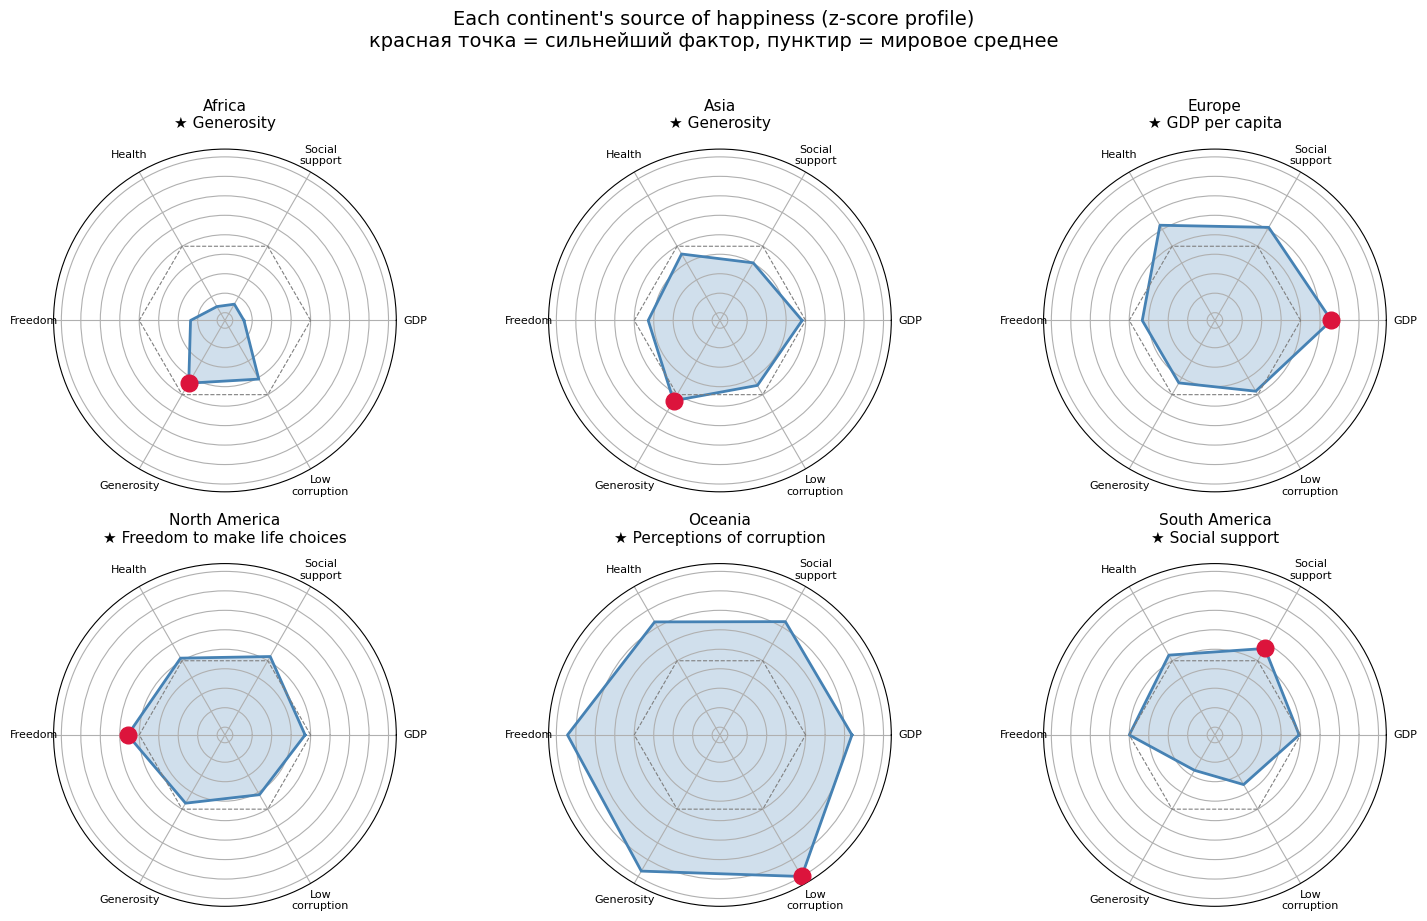

In [39]:
import matplotlib.pyplot as plt
import numpy as np

factors = ["GDP per capita", "Social support", "Healthy life expectancy",
           "Freedom to make life choices", "Generosity", "Perceptions of corruption"]
short = ["GDP", "Social\nsupport", "Health", "Freedom", "Generosity", "Low\ncorruption"]

cont_means = df.groupby("Continent")[factors].mean()
z = (cont_means - cont_means.mean()) / cont_means.std()   # z-score между континентами

N = len(factors)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # замкнуть полигон

conts = list(z.index)
ncols = 3
nrows = int(np.ceil(len(conts) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows),
                         subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, cont in enumerate(conts):
    ax = axes[idx]
    vals = z.loc[cont].tolist()
    vals += vals[:1]

    ax.plot(angles, vals, color="steelblue", linewidth=2)
    ax.fill(angles, vals, color="steelblue", alpha=0.25)
    ax.plot(angles, [0] * len(angles), color="gray", linestyle="--", linewidth=0.8)  # мировое среднее

    # Сильнейший фактор континента
    strongest = int(np.argmax(z.loc[cont].values))
    ax.plot(angles[strongest], z.loc[cont].values[strongest], "o",
            color="crimson", markersize=12, zorder=5)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(short, fontsize=8)
    ax.set_yticklabels([])
    ax.set_ylim(-2.2, 2.2)
    ax.set_title(f"{cont}\n★ {factors[strongest]}", fontsize=11, pad=15)

# Скрыть лишние пустые ячейки сетки
for k in range(len(conts), len(axes)):
    axes[k].set_visible(False)

fig.suptitle("Each continent's source of happiness (z-score profile)\n"
             "красная точка = сильнейший фактор, пунктир = мировое среднее",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()